In [43]:
# ==============================================================
# CELL 1 — Imports & Configuration
# ==============================================================
# Configure scan pairs, input/output directories, and LiMatch settings.
# Each pair (sid_a, t_crop_a, sid_b, t_crop_b) defines two scan windows
# to match using LiMatch. Only VUX points (scanner_src == 2) are used.
# ==============================================================

import numpy as np
import laspy
import pandas as pd
from pathlib import Path
import sys
from collections import defaultdict

# ── Pipeline import ───────────────────────────────────────────
PIPELINE_DIR = Path("/home/b085164/PDM_Romain_Defferrard/ESO-PDM/pipeline")
sys.path.insert(0, str(PIPELINE_DIR.parent))

from pipeline.steps.limatch import _run_pair, _repo_root

REPO_ROOT    = _repo_root()
LIMATCH_CFG  = REPO_ROOT / "Patcher/submodules/limatch/configs/MLS.yml"

# ── Data directories ─────────────────────────────────────────
BASE         = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/")
COMBINED_DIR = BASE / "georef_COMBINED" / "merged" / "ALL"
OUTAGE_DIR   = BASE / "merged" / "ALL"
OUT_BASE     = BASE / "L2L_eval"
OUT_BASE.mkdir(parents=True, exist_ok=True)



# ── Scan pairs ────────────────────────────────────────────────
# Format: (scan_id_a, (t_start_a, t_end_a), scan_id_b, (t_start_b, t_end_b))

# Outage ECCR
# PAIRS = [
#     (2000, (315700, 315710), 3000, (315745, 315756)),  
#     (1000, (315644, 315650), 4000, (315799, 315809)), 
#     (4000, (315815, 315830), 8000, (316051, 316065)),
#     (5000, (315848, 315861), 6000, (315915, 315925)),
#     (6000, (315926, 315940), 8000, (316028, 316038)),
#     (7000, (315972, 315979), 8000, (316024, 316032)),
# ]

# Outage 1 CALIB
# PAIRS = [
#     (2000, (305365, 305371), 3000, (305439, 305447)),
#     (2000, (305330, 305340), 3000, (305473, 305485)),
#     (1000, (305264, 305272), 3000, (305547, 305556)),
# ]

# Outage 2 CALIB
PAIRS = [
    (9000, (305809, 305814), 10000, (305864, 305870)),
    (4000, (305749, 305753), 7000, (305775, 305781)),
    (18000, (305955, 305961), 19000, (306091, 306097)),

]

# Outage 3 CALIB 
# PAIRS = [
#     (1000, (306310, 306315), 5000, (306622, 306627)),  
#     (1000, (306335, 306340), 5000, (306596, 306601)),  
#     (2000, (306383, 306395), 5000, (306574, 306581)),
# ]






print(f"{len(PAIRS)} paires configurées")
for i, (sa, ta, sb, tb) in enumerate(PAIRS):
    dt = tb[0] - ta[1]
    print(f"  Paire {i+1}: merged_{sa} [{ta[0]}-{ta[1]}] ↔ merged_{sb} [{tb[0]}-{tb[1]}]  Δt≈{dt:.0f}s")

3 paires configurées
  Paire 1: merged_9000 [305809-305814] ↔ merged_10000 [305864-305870]  Δt≈50s
  Paire 2: merged_4000 [305749-305753] ↔ merged_7000 [305775-305781]  Δt≈22s
  Paire 3: merged_18000 [305955-305961] ↔ merged_19000 [306091-306097]  Δt≈130s


In [ ]:
# ── Group crops by source file ────────────────────────────────
# One read per source file — avoids reloading the same LAS multiple times.
from collections import defaultdict

# {las_path: [(out_path, t0, t1), ...]}
crops_by_file = defaultdict(list)

for i, (sid_a, t_crop_a, sid_b, t_crop_b) in enumerate(PAIRS):
    out_dir = OUT_BASE / f"pair_{i+1}_{sid_a}_{sid_b}"
    out_dir.mkdir(parents=True, exist_ok=True)

    src_a = COMBINED_DIR / f"merged_{sid_a}_VUX_PUCK.las"
    src_b = COMBINED_DIR / f"merged_{sid_b}_VUX_PUCK.las"

    crops_by_file[src_a].append((out_dir / f"scan_{sid_a}_crop.las", *t_crop_a))
    crops_by_file[src_b].append((out_dir / f"scan_{sid_b}_crop.las", *t_crop_b))

# ── One read per source file ──────────────────────────────────
out_path_map = {}   # {out_path: Path | None}

for las_path, crop_list in crops_by_file.items():
    # Check if all crops already exist
    all_exist = all(out_path.exists() for out_path, t0, t1 in crop_list)
    if all_exist:
        print(f"[SKIP] {las_path.name} — all crops exist")
        for out_path, t0, t1 in crop_list:
            out_path_map[out_path] = out_path
        continue

    print(f"\nReading: {las_path.name}")
    las = laspy.read(las_path)
    t   = np.asarray(las.gps_time)
    src = np.asarray(las.scanner_src)
    vux_mask = (src == 2)   # VUX only

    for out_path, t0, t1 in crop_list:
        if out_path.exists():
            print(f"  [SKIP] {out_path.name}")
            out_path_map[out_path] = out_path
            continue

        mask   = vux_mask & (t >= t0) & (t <= t1)
        n_kept = int(mask.sum())
        print(f"  [{t0:.1f}, {t1:.1f}] → {n_kept:,} pts", end=" ")

        if n_kept == 0:
            print(f"!! empty")
            out_path_map[out_path] = None
            continue

        las[mask].write(out_path)
        print(f"→ {out_path.name}")
        out_path_map[out_path] = out_path

# ── Rebuild crop_paths in pair order ─────────────────────────
crop_paths = []
for i, (sid_a, t_crop_a, sid_b, t_crop_b) in enumerate(PAIRS):
    out_dir = OUT_BASE / f"pair_{i+1}_{sid_a}_{sid_b}"
    path_a  = out_path_map.get(out_dir / f"scan_{sid_a}_crop.las")
    path_b  = out_path_map.get(out_dir / f"scan_{sid_b}_crop.las")
    crop_paths.append((i, out_dir, path_a, path_b))

print(f"\nCrop done — {len(crop_paths)} pairs.")


Lecture : merged_9000_VUX_PUCK.las
  [305809.0, 305814.0] → 6,016,477 pts → scan_9000_crop.las

Lecture : merged_10000_VUX_PUCK.las
  [305864.0, 305870.0] → 7,719,764 pts → scan_10000_crop.las

Lecture : merged_4000_VUX_PUCK.las
  [305749.0, 305753.0] → 3,548,728 pts → scan_4000_crop.las

Lecture : merged_7000_VUX_PUCK.las
  [305775.0, 305781.0] → 5,441,729 pts → scan_7000_crop.las

Lecture : merged_18000_VUX_PUCK.las
  [305955.0, 305961.0] → 5,379,236 pts → scan_18000_crop.las

Lecture : merged_19000_VUX_PUCK.las
  [306091.0, 306097.0] → 5,765,315 pts → scan_19000_crop.las

Crop terminé — 3 paires.


[10:57:34] INFO | Starting LiMatch pipeline...
[10:57:34] INFO |   └─ Will save data at: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_1_9000_10000/limatch/
[10:57:34] INFO | Visualization set to False
[10:57:34] INFO | [0/7] Model setup
[10:57:34] INFO |   └─ Using CUDA for descriptor inference.
[10:57:34] INFO |   └─ Loading from: /home/b085164/PDM_Romain_Defferrard/ESO-PDM/Patcher/submodules/limatch/weights/model.pth
[10:57:34] INFO |   └─ Loaded nested checkpoint with key 'model'.
[10:57:34] INFO |   └─ Descriptor model successfully loaded and set to eval() mode.
[10:57:34] INFO | [1/7] Preprocessing
[10:57:34] INFO |   └─ Loading point clouds...



LiMatch paire 1
[limatch-api] prj_folder=/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_1_9000_10000/limatch/


[10:57:34] INFO |   └─ Loaded laser vectors from LAS extra bytes: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_1_9000_10000/scan_9000_crop.las
[10:57:36] INFO |   └─ Loaded laser vectors from LAS extra bytes: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_1_9000_10000/scan_10000_crop.las
[10:57:38] INFO |   └─ No tiling... (all points kept)
[10:57:38] INFO |   └─ Shifting point clouds toward origin...
[10:57:38] INFO |       └─ [2542685.96 1157354.97     909.85] m...
[10:57:38] INFO |       └─ (Coordinates shifted back at export)
[10:57:41] INFO |   └─ Generated 1 valid tiles.
[10:57:41] INFO |   └─ Applying voxelization with size 0.025 m...
[10:57:45] INFO |       └─ voxelized from 6016477 to 3003391 pts (49.92%)
[10:57:50] INFO |       └─ voxelized from 7719764 to 3802696 pts (49.26%)
[10:57:51] INFO | [2/7] Keypoint detection
[10:58:00] INFO |   └─ Downsampling keypoints to max 25000 

1.5


[10:58:15] INFO |   └─ get_candidates 100% — avg candidates/kpt: 388
[10:58:15] INFO |   └─ get_candidates B→A (19411 kpts)...
[10:58:15] INFO |   └─ get_candidates — r_min=0.0m  r_max=3.0m  (19411 kpts)


...

  → corres_scan_4000_crop_scan_7000_crop.txt

LiMatch paire 3
[limatch-api] prj_folder=/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_3_18000_19000/limatch/


[11:09:24] INFO |   └─ Loaded laser vectors from LAS extra bytes: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_3_18000_19000/scan_18000_crop.las
[11:09:26] INFO |   └─ Loaded laser vectors from LAS extra bytes: /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_3_18000_19000/scan_19000_crop.las
[11:09:27] INFO |   └─ No tiling... (all points kept)
[11:09:27] INFO |   └─ Shifting point clouds toward origin...
[11:09:27] INFO |       └─ [2542645.76 1157300.77     906.08] m...
[11:09:27] INFO |       └─ (Coordinates shifted back at export)
[11:09:29] INFO |   └─ Generated 1 valid tiles.
[11:09:29] INFO |   └─ Applying voxelization with size 0.025 m...
[11:09:32] INFO |       └─ voxelized from 5379236 to 2181191 pts (40.55%)
[11:09:35] INFO |       └─ voxelized from 5765315 to 2556563 pts (44.34%)
[11:09:36] INFO | [2/7] Keypoint detection
[11:09:41] INFO |   └─ Downsampling keypoints to max 250

1.5
1.5


[11:09:47] INFO |   └─ feat_search B→A (11697 kpts)...
[11:09:48] INFO |   └─ Applying reciprocity test...
[11:09:48] INFO |   └─ Keeping 15.79% reciprocal matches
[11:09:48] INFO | [5/7] RANSAC filtering
[11:09:48] INFO |   └─ Tile 1: keeping 51.77%
[11:09:48] INFO | [6/7] ICP refinement
[11:09:48] INFO |   └─ ICP refining tile 1 with 849 correspondences...
[11:10:11] INFO | [7/7] Building output
[11:10:11] INFO |   └─ Loading trajectory from SBET: /media/b085164/Elements/CALIB_26_02_25/ODyN_calib/AIRINS/Outage_2_305645_306120/COMBINED/out/traj_COMBINED_2.out...
[11:10:11] INFO |       └─ Loaded 39900 trajectory points.
[11:10:11] INFO |       └─ Time span: 304790.004265 to 306784.9542645355 s.
[11:10:12] INFO |   └─ Using input laser vectors for correspondences...
[11:10:12] INFO |   └─ Correcting laser vectors B with ICP results...
[11:10:12] INFO |   └─ Saving to /media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_2/relative_error_eval_VUX_v2/pair_3_18000_19000/limatch/co

  → corres_scan_18000_crop_scan_19000_crop.txt

3/3 paires avec correspondances.


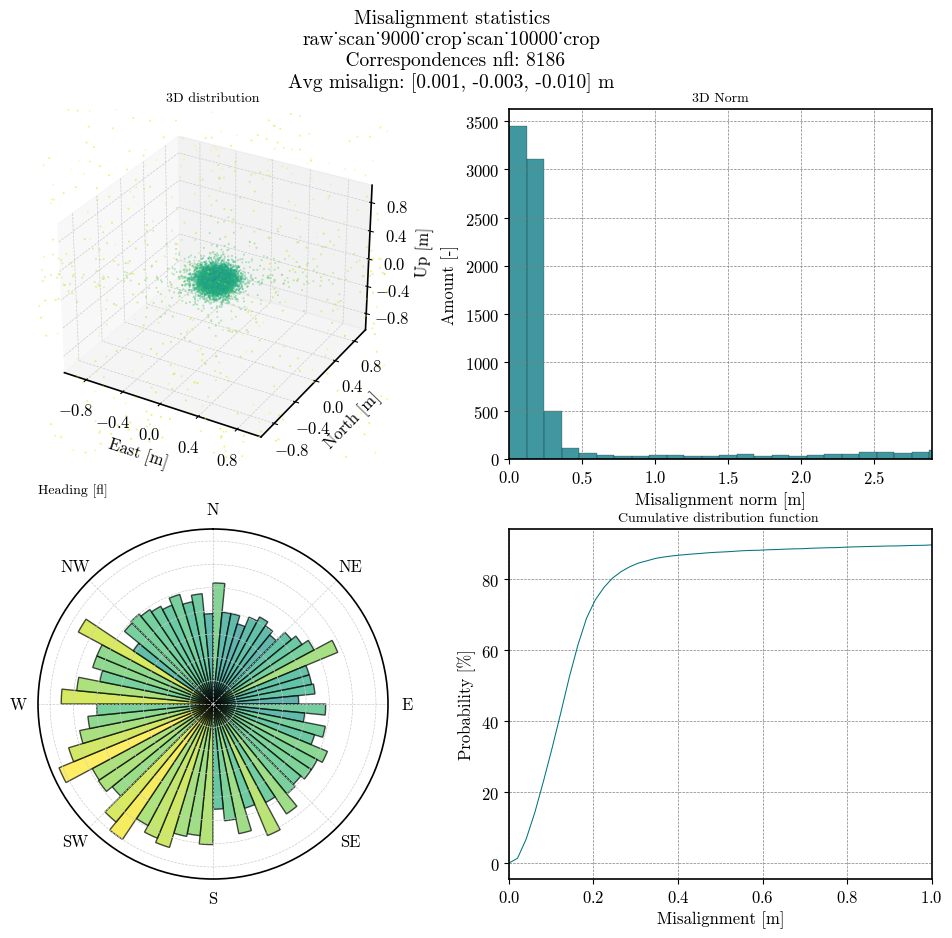

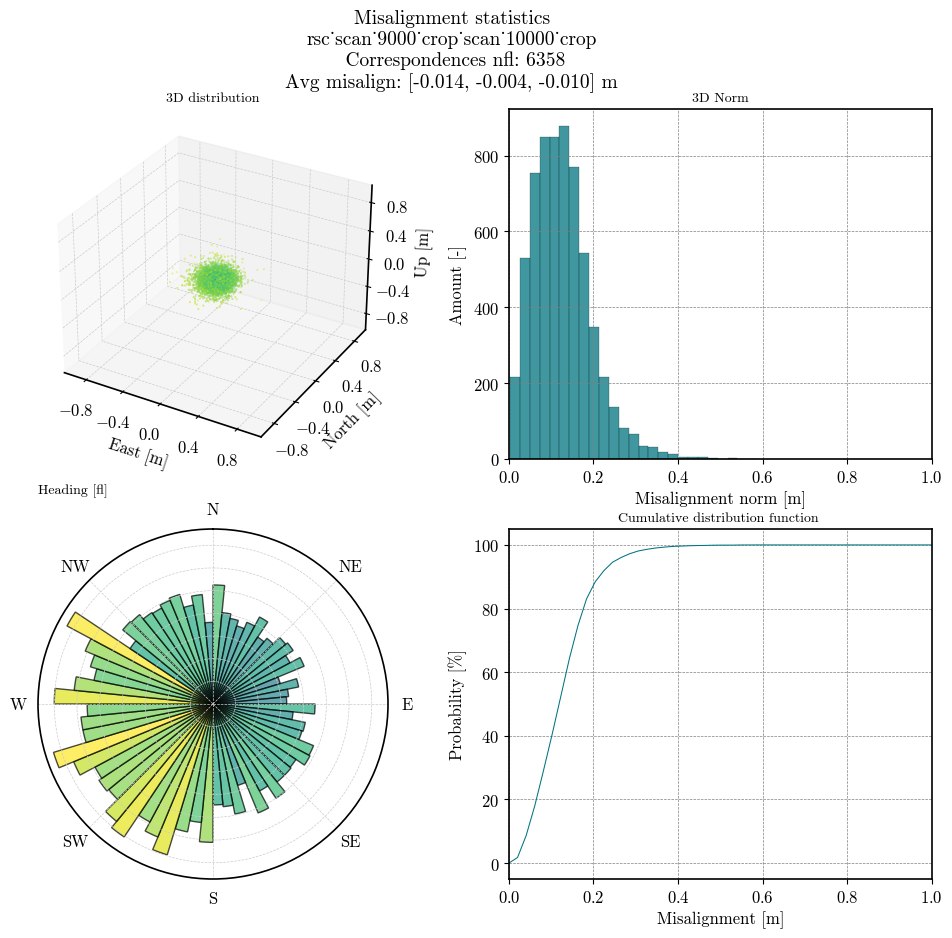

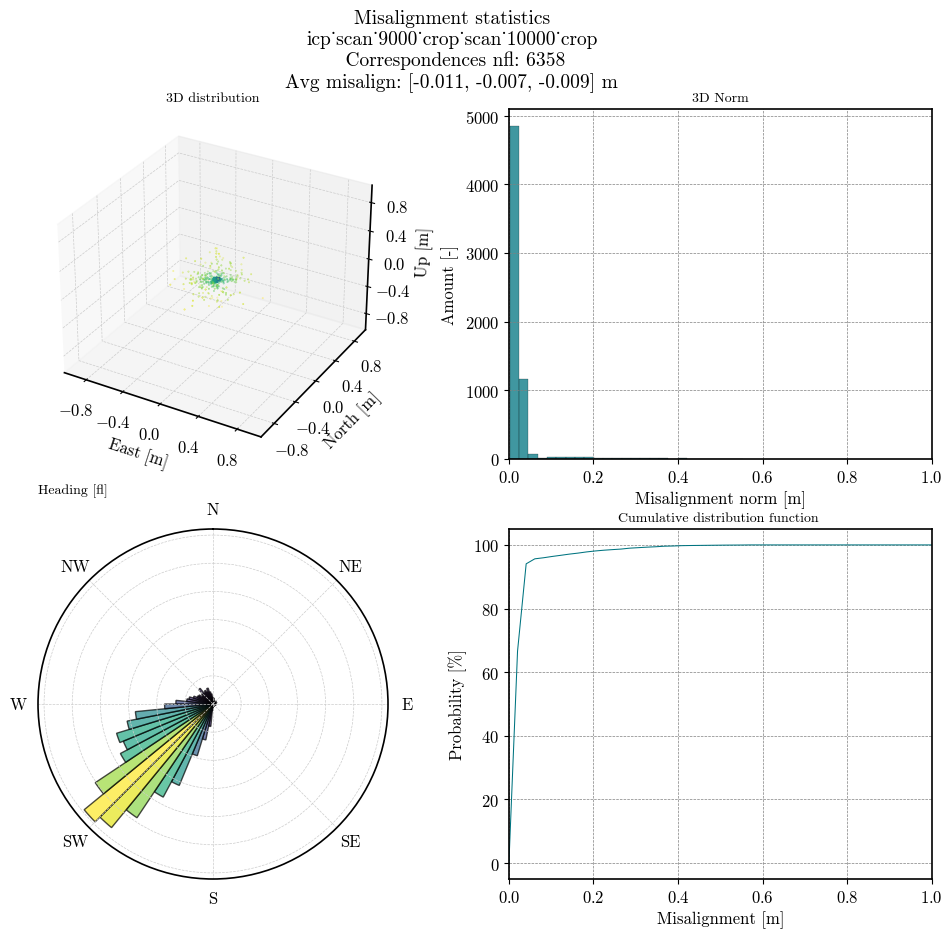

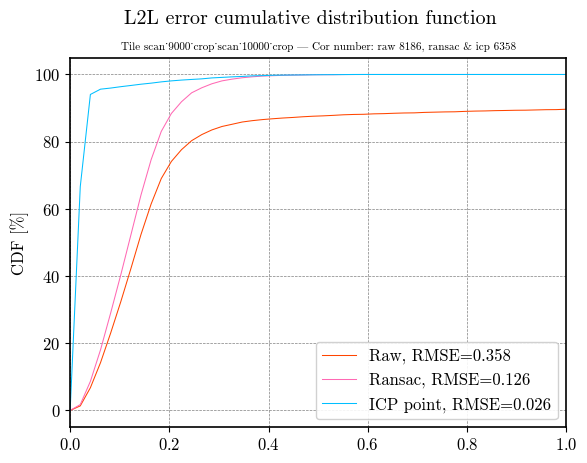

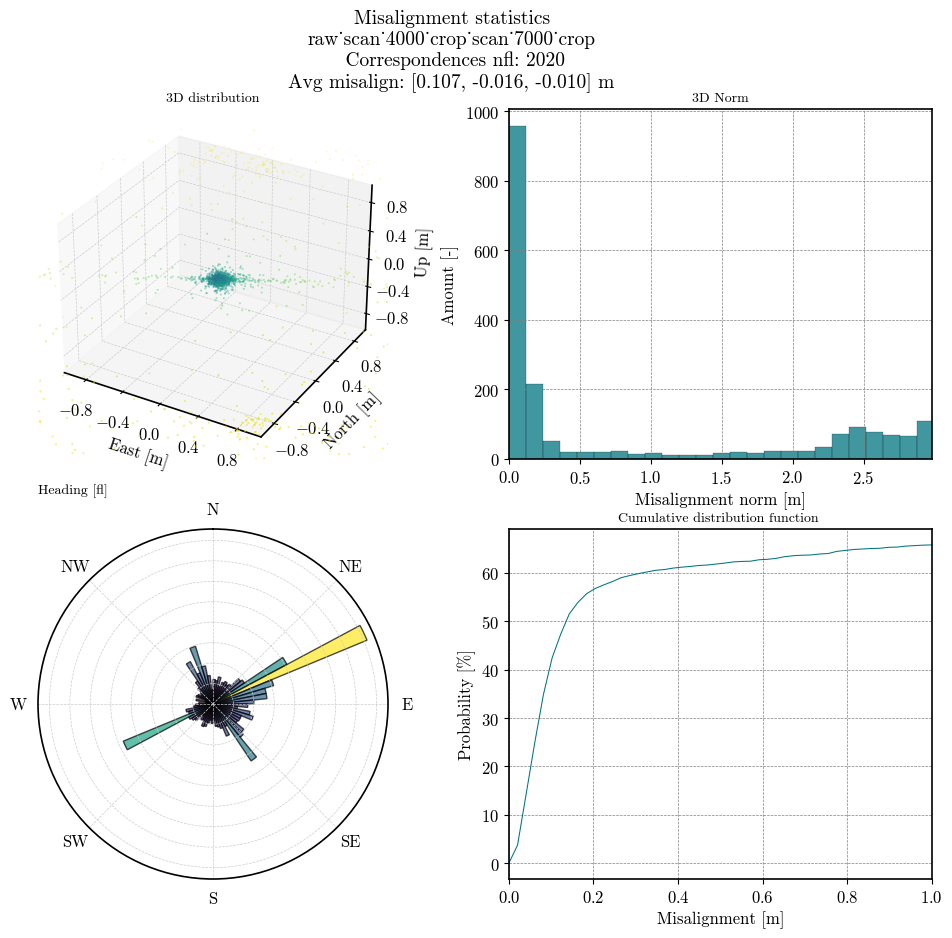

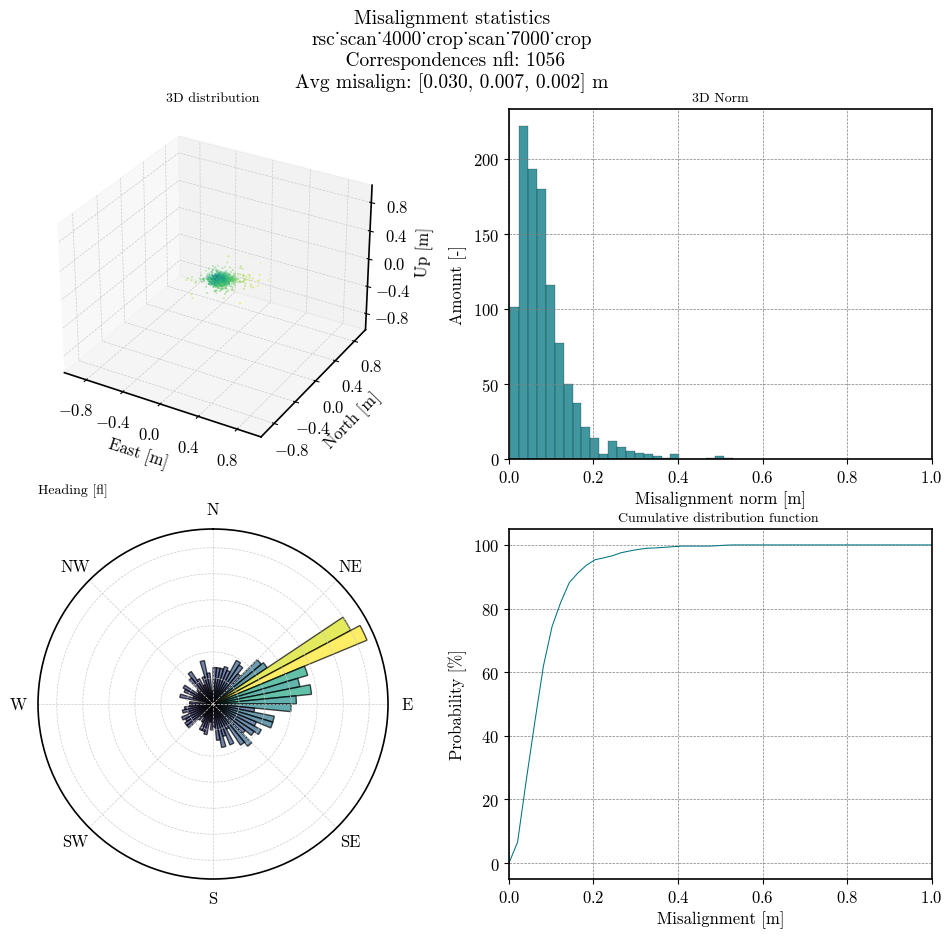

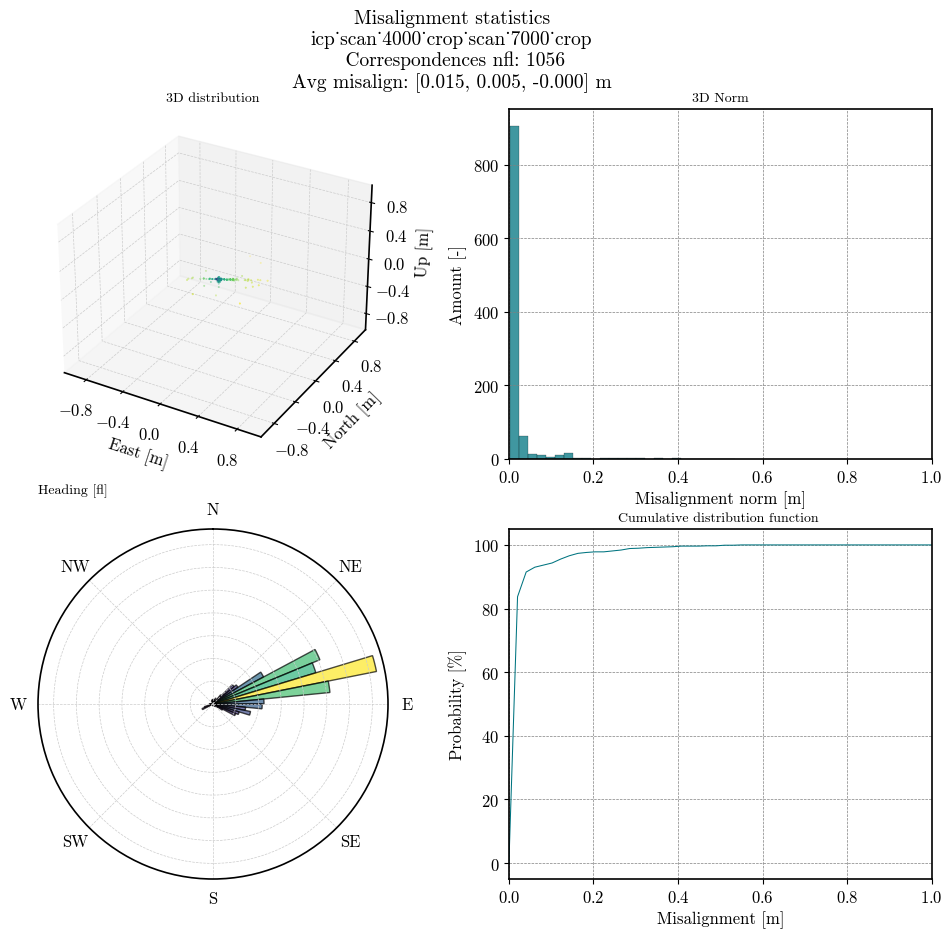

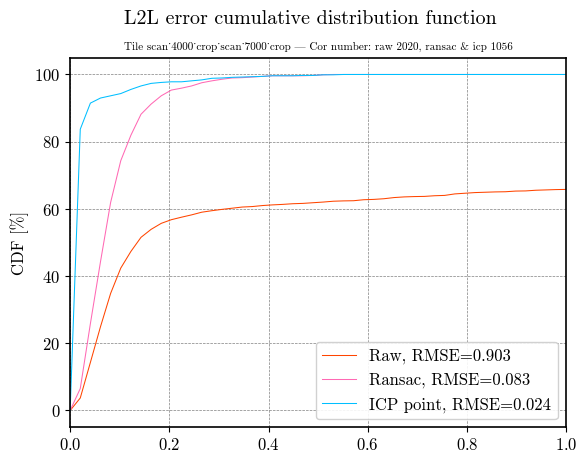

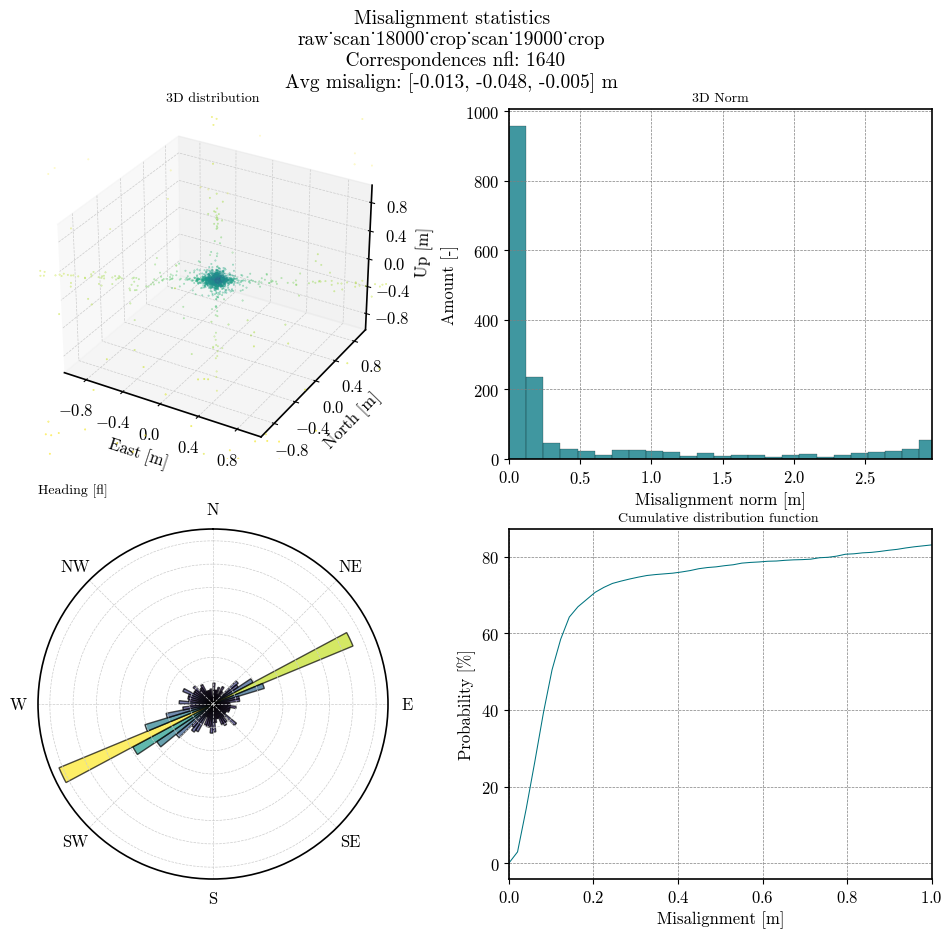

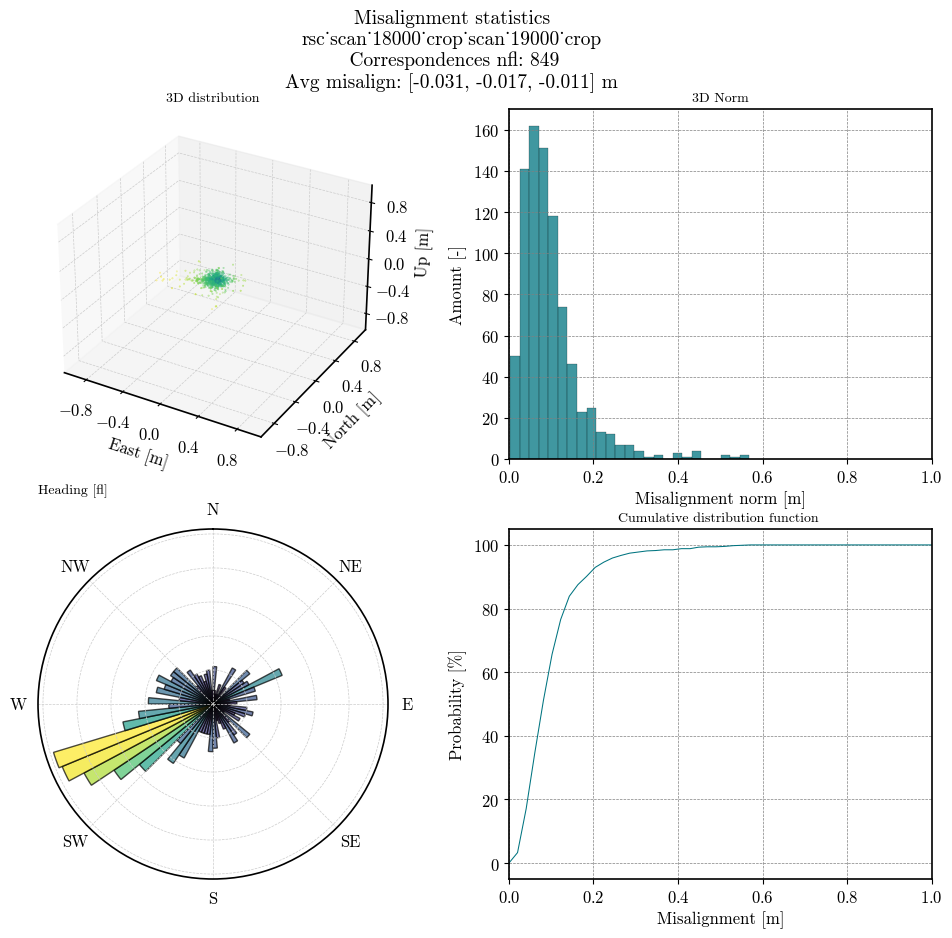

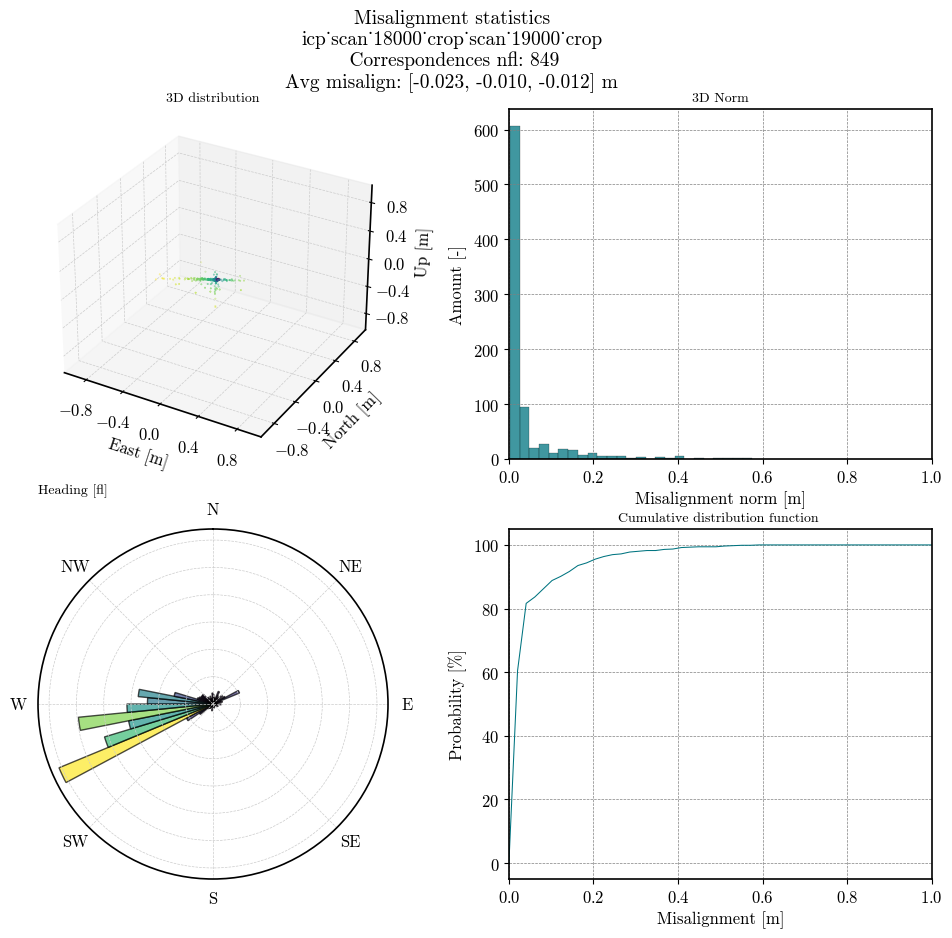

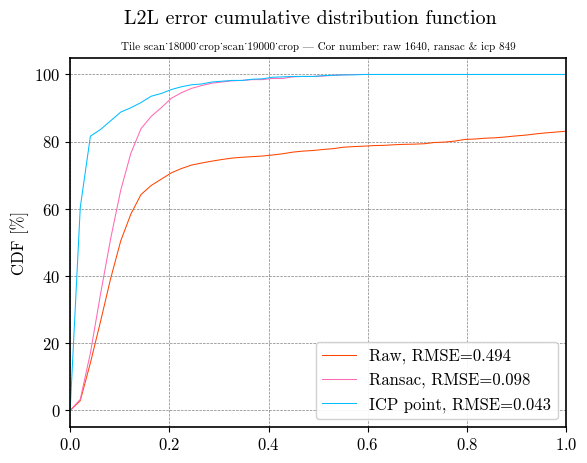

In [ ]:
# ==============================================================
# CELL 3 — Run LiMatch on all pairs
# ==============================================================

import matplotlib
matplotlib.use("Agg")   # suppress LiMatch plots

LM_CFG = {"uncertainty_r": 1.5}

limatch_results = []

for i, out_dir, out_a, out_b in crop_paths:
    if out_a is None or out_b is None:
        print(f"Pair {i+1} — empty crop, skip")
        continue

    lm_dir = out_dir / "limatch"

    # Skip if already done
    existing = list(lm_dir.rglob("corres_*.txt"))
    if existing:
        print(f"Pair {i+1} — [SKIP] correspondence file exists: {existing[0].name}")
        limatch_results.append((i, out_dir, existing[0]))
        continue

    print(f"\n{'='*55}\nLiMatch pair {i+1}\n{'='*55}")
    _run_pair(
        limatch_cfg_path=LIMATCH_CFG,
        cloud1=out_a,
        cloud2=out_b,
        out_dir=lm_dir,
        lim_pipeline_cfg=LM_CFG,
    )

    corres_files = list(lm_dir.rglob("corres_*.txt"))
    if corres_files:
        limatch_results.append((i, out_dir, corres_files[0]))
        print(f"  → {corres_files[0].name}")
    else:
        print(f"  !! No corres_*.txt produced")

print(f"\n{len(limatch_results)}/{len(PAIRS)} pairs with correspondences.")

In [ ]:
# ==============================================================
# CELL 4 — Compute relative L2L error (Combined vs Outage)
# ==============================================================
# For each LiMatch pair, retrieves matched point positions from
# both the Combined and Outage clouds using GPS timestamps.
# Computes d_combined (LiMatch residual) and d_outage (3D distance
# between the same laser returns in the outage trajectory cloud).
# ==============================================================

CORRES_COLS = ["time_a", "x_a", "y_a", "z_a",
               "time_b", "x_b", "y_b", "z_b",
               "d_xyz", "icp_x", "icp_y", "icp_z"]

def load_corres(path):
    df = pd.read_csv(path, header=None, names=CORRES_COLS,
                     sep=r",\s*", engine="python", skiprows=1)
    return df.apply(pd.to_numeric, errors="coerce").dropna()

def get_xyz_for_times(las_path, times_list, tol=1e-9):
    """
    Load a LAS file, sort by GPS time, and retrieve XYZ for each
    requested timestamp via searchsorted.
    """
    times_arr = np.array(list(times_list), dtype=np.float64)

    las = laspy.read(las_path)
    t   = np.asarray(las.gps_time, dtype=np.float64)
    x   = np.asarray(las.x,        dtype=np.float64)
    y   = np.asarray(las.y,        dtype=np.float64)
    z   = np.asarray(las.z,        dtype=np.float64)

    order = np.argsort(t)
    t = t[order]; x = x[order]; y = y[order]; z = z[order]

    result = {}
    n_ambig = 0
    for ti in times_arr:
        idx = np.searchsorted(t, ti)
        candidates = []
        for j in [idx-1, idx, idx+1]:
            if 0 <= j < len(t) and abs(t[j] - ti) < tol:
                candidates.append(j)
        if len(candidates) == 1:
            j = candidates[0]
            result[ti] = np.array([x[j], y[j], z[j]])
        elif len(candidates) > 1:
            n_ambig += 1

    n_miss = len(times_arr) - len(result) - n_ambig
    print(f"    {len(result)}/{len(times_arr)} found  "
          f"|  {n_ambig} ambiguous  |  {n_miss} missing")
    return result

# --- Evaluation ---
all_rows = []

for i, out_dir, corres_path in limatch_results:
    sid_a, t_crop_a, sid_b, t_crop_b = \
        PAIRS[i][0], PAIRS[i][1], PAIRS[i][2], PAIRS[i][3]
    dt_outage = t_crop_b[0] - t_crop_a[1]

    print(f"\nPair {i+1} — merged_{sid_a} / merged_{sid_b}  Δt≈{dt_outage:.0f}s")

    # 1. Load correspondences
    df_corres = load_corres(corres_path)
    print(f"  {len(df_corres)} correspondences")

    # 2. Required timestamps
    times_a = set(df_corres["time_a"].values)
    times_b = set(df_corres["time_b"].values)

    # 3. Look up in scan A
    print(f"  File A — merged_{sid_a}:")
    xyz_a = get_xyz_for_times(
        OUTAGE_DIR / f"merged_{sid_a}_VUX_PUCK.las", times_a)

    # 4. Look up in scan B
    print(f"  File B — merged_{sid_b}:")
    xyz_b = get_xyz_for_times(
        OUTAGE_DIR / f"merged_{sid_b}_VUX_PUCK.las", times_b)

    # 5. Compute d_outage for each correspondence
    n_found = n_miss = 0
    for _, row in df_corres.iterrows():
        ta = row["time_a"]
        tb = row["time_b"]

        P_a = xyz_a.get(ta, None)
        P_b = xyz_b.get(tb, None)

        if P_a is None or P_b is None:
            n_miss += 1
            continue

        n_found += 1
        all_rows.append({
            "pair":       i + 1,
            "dt_outage":  dt_outage,
            "time_a":     ta,
            "time_b":     tb,
            "d_combined": float(row["d_xyz"]),
            "d_outage":   float(np.linalg.norm(P_a - P_b)),
        })

    print(f"  → {n_found} evaluated  |  {n_miss} not found")

df_all = pd.DataFrame(all_rows)

# Summary statistics
print("\n--- Summary ---")
print(f"{'':12} {'N':>6} {'Q50 [cm]':>10} {'Q95 [cm]':>10} {'RMSE [cm]':>10}")
print("-"*50)
for label, col in [("Combined", "d_combined"), ("Outage", "d_outage")]:
    d = df_all[col].dropna().values * 100
    print(f"  {label:<10} {len(d):>6} {np.median(d):>10.2f} "
          f"{np.percentile(d,95):>10.2f} {np.sqrt(np.mean(d**2)):>10.2f}")


Paire 1 — merged_9000 / merged_10000  Δt≈50s
  6358 correspondances
  Fichier A — merged_9000:
    2709/6345 trouvés  |  3636 ambigus  |  0 absents
  Fichier B — merged_10000:
    2483/6349 trouvés  |  3866 ambigus  |  0 absents
  → 1453 évaluées  |  4905 non trouvées

Paire 2 — merged_4000 / merged_7000  Δt≈22s
  1056 correspondances
  Fichier A — merged_4000:
    949/1056 trouvés  |  107 ambigus  |  0 absents
  Fichier B — merged_7000:
    943/1056 trouvés  |  113 ambigus  |  0 absents
  → 892 évaluées  |  164 non trouvées

Paire 3 — merged_18000 / merged_19000  Δt≈130s
  849 correspondances
  Fichier A — merged_18000:
    767/849 trouvés  |  82 ambigus  |  0 absents
  Fichier B — merged_19000:
    716/848 trouvés  |  132 ambigus  |  0 absents
  → 663 évaluées  |  186 non trouvées

--- Summary ---
                  N   Q50 [cm]   Q95 [cm]  RMSE [cm]
--------------------------------------------------
  Combined     3008       1.40      14.60       7.04
  Outage       3008     111.42 

# L2L per distance range

In [ ]:
# ==============================================================
# CELL 5 — L2L error stratified by scan range
# ==============================================================
# Joins LiMatch correspondences with laser vector files to retrieve
# the scan range (norm of the laser vector) for each point.
# Reports Combined and Outage RMSE per range bin [0-10m, 10-20m, 20-30m].
# ==============================================================

P2P_VEC_COLS = ["time_a", "time_b",
                "vx_a", "vy_a", "vz_a",
                "vx_b", "vy_b", "vz_b"]

BINS       = [(0, 10), (10, 20), (20, 30)]
BIN_LABELS = ["0-10m", "10-20m", "20-30m"]

all_rows_range = []

for i, out_dir, corres_path in limatch_results:
    sid_a = PAIRS[i][0]
    sid_b = PAIRS[i][2]

    # Find the LiDAR_p2p file with laser vectors
    p2p_files = list(corres_path.parent.glob("LiDAR_p2p_scan*.txt"))
    if not p2p_files:
        print(f"  Pair {i+1} — no LiDAR_p2p_scan*.txt found, skip")
        continue
    p2p_path = p2p_files[0]

    # Load laser vectors
    df_vec = pd.read_csv(p2p_path, header=None, names=P2P_VEC_COLS,
                         sep=r",\s*", engine="python")
    df_vec = df_vec.apply(pd.to_numeric, errors="coerce").dropna()

    # Scan range = norm of the laser vector
    df_vec["r_a"] = np.sqrt(df_vec["vx_a"]**2 +
                             df_vec["vy_a"]**2 +
                             df_vec["vz_a"]**2)

    # Load correspondences
    df_corres = load_corres(corres_path)

    # Rename columns for correct join
    df_vec_renamed = df_vec.rename(columns={
        "time_a": "time_b_vec",
        "time_b": "time_a",      # vec time_b = corres time_a
        "vx_a": "vx_b", "vy_a": "vy_b", "vz_a": "vz_b",
        "vx_b": "vx_a", "vy_b": "vy_a", "vz_b": "vz_a",
        "r_a": "r_b"
    })

    # Recompute r_a from renamed vectors
    df_vec_renamed["r_a"] = np.sqrt(df_vec_renamed["vx_a"]**2 +
                                    df_vec_renamed["vy_a"]**2 +
                                    df_vec_renamed["vz_a"]**2)

    df_merged = pd.merge(
        df_corres[["time_a", "time_b", "d_xyz"]],
        df_vec_renamed[["time_a", "r_a"]],
        on="time_a",
        how="inner"
    )
    print(f"  Pair {i+1}: {len(df_merged)}/{len(df_corres)} matched with range")
    print(df_merged["r_a"].describe())

    # Merge with d_outage if available from previous cell
    if 'df_all' in dir() and len(df_all) > 0:
        df_out = df_all[df_all["pair"] == i+1][["time_a", "time_b", "d_outage"]]
        df_merged = pd.merge(df_merged, df_out,
                             on=["time_a", "time_b"], how="left")
    else:
        df_merged["d_outage"] = np.nan

    for _, row in df_merged.iterrows():
        all_rows_range.append({
            "pair":       i + 1,
            "r_a":        row["r_a"],
            "d_combined": row["d_xyz"],
            "d_outage":   row.get("d_outage", np.nan),
        })

df_range = pd.DataFrame(all_rows_range)

# ── Stats per range bin ───────────────────────────────────────
print(f"\n{'Bin':<10} {'N':>7} {'Comb Q50 [cm]':>14} "
      f"{'Comb RMSE [cm]':>15} {'Out RMSE [cm]':>14}")
print("-" * 65)

for (r_min, r_max), label in zip(BINS, BIN_LABELS):
    mask = (df_range["r_a"] >= r_min) & (df_range["r_a"] < r_max)
    sub  = df_range[mask]
    if len(sub) == 0:
        print(f"  {label:<8} — no data")
        continue
    d_c = sub["d_combined"].values * 100
    d_o = sub["d_outage"].dropna().values * 100
    print(f"  {label:<8} {len(sub):>7} "
          f"{np.median(d_c):>14.2f} "
          f"{np.sqrt(np.mean(d_c**2)):>15.2f} "
          f"{np.sqrt(np.mean(d_o**2)) if len(d_o) > 0 else float('nan'):>14.2f}")

# Global
d_c = df_range["d_combined"].values * 100
d_o = df_range["d_outage"].dropna().values * 100
print(f"  {'Global':<8} {len(df_range):>7} "
      f"{np.median(d_c):>14.2f} "
      f"{np.sqrt(np.mean(d_c**2)):>15.2f} "
      f"{np.sqrt(np.mean(d_o**2)) if len(d_o) > 0 else float('nan'):>14.2f}")

  Paire 1: 2595/2595 matchés avec range
count    2595.000000
mean       22.256245
std         5.890612
min         2.993260
25%        19.816002
50%        23.589869
75%        26.475175
max        30.023586
Name: r_a, dtype: float64
  Paire 2: 4863/4849 matchés avec range
count    4863.000000
mean       16.714023
std         6.753792
min         3.014238
25%        10.274205
50%        18.180619
75%        22.315971
max        30.779754
Name: r_a, dtype: float64
  Paire 3: 3795/3785 matchés avec range
count    3795.000000
mean       23.558040
std         3.665376
min         3.390720
25%        21.074310
50%        23.729615
75%        26.237723
max        31.615076
Name: r_a, dtype: float64

Bin              N  Comb Q50 [cm]  Comb RMSE [cm]  Out RMSE [cm]
-----------------------------------------------------------------
  0-10m       1315           1.70            8.81            nan
  10-20m      2775           1.60            9.39            nan
  20-30m      7086           1.20   

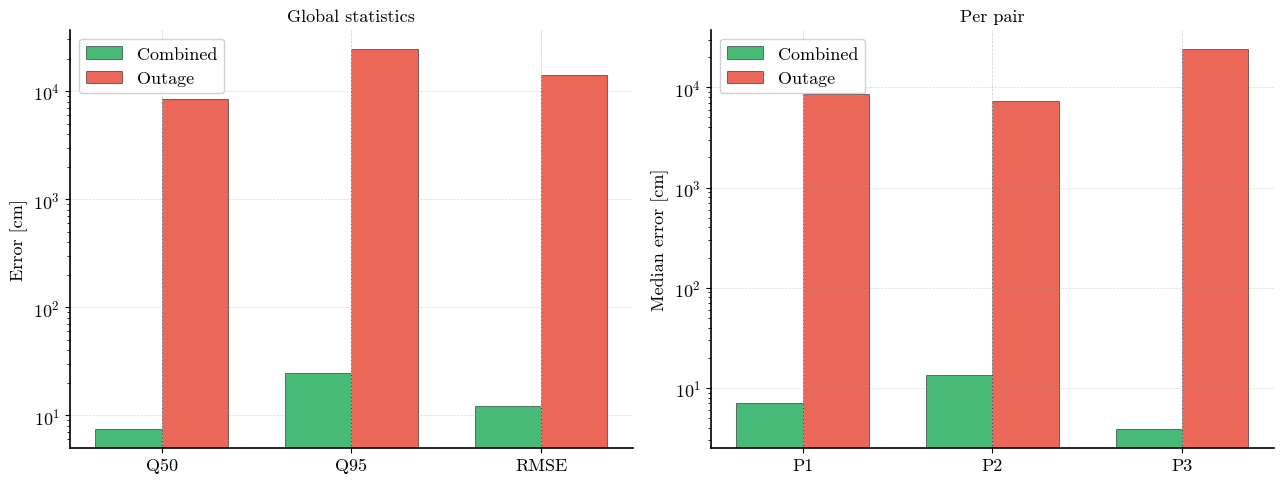


--- Relative error summary ---
Scenario          N   Q50 [cm]   Q95 [cm]  RMSE [cm]
--------------------------------------------------
  Combined     2793       7.50      24.90      12.26
  Outage       2793    8471.97   24663.78   14149.56


In [24]:
import matplotlib.pyplot as plt

COLORS = {"Combined": "#27ae60", "Outage": "#e74c3c"}
FS = 13

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- AX1 : stats globales ---
x2 = np.arange(3)
for j, (label, col) in enumerate([("Combined", "d_combined"),
                                   ("Outage",   "d_outage")]):
    d    = df_all[col].dropna().values * 100
    vals = [np.median(d), np.percentile(d, 95), np.sqrt(np.mean(d**2))]
    ax1.bar(x2 + j*0.35, vals, width=0.35,
            color=COLORS[label], alpha=0.85, label=label,
            edgecolor="k", lw=0.4)

ax1.set_xticks(x2 + 0.175)
ax1.set_xticklabels(["Q50", "Q95", "RMSE"], fontsize=FS)
ax1.set_ylabel("Error [cm]", fontsize=FS)
ax1.set_title("Global statistics", fontsize=FS)
ax1.set_yscale("log")
ax1.tick_params(axis="both", labelsize=FS)
ax1.legend(fontsize=FS)
ax1.grid(axis="y", color="grey", ls="--", alpha=0.3)
ax1.spines[["top","right"]].set_visible(False)

# --- AX2 : médiane par paire ---
pair_ids = sorted(df_all["pair"].unique())
x = np.arange(len(pair_ids))
width = 0.35

for j, (label, col) in enumerate([("Combined", "d_combined"),
                                   ("Outage",   "d_outage")]):
    medians = [df_all[df_all["pair"]==p][col].median()*100 for p in pair_ids]
    ax2.bar(x + j*width, medians, width=width,
            color=COLORS[label], alpha=0.85, label=label,
            edgecolor="k", lw=0.4)

ax2.set_xticks(x + width/2)
ax2.set_xticklabels([f"P{p}" for p in pair_ids], fontsize=FS)
ax2.set_ylabel("Median error [cm]", fontsize=FS)
ax2.set_title("Per pair", fontsize=FS)
ax2.set_yscale("log")
ax2.tick_params(axis="both", labelsize=FS)
ax2.legend(fontsize=FS)
ax2.grid(axis="y", color="grey", ls="--", alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(str(OUT_BASE / "relative_error_global_AIRINS_out1.png"), dpi=400, bbox_inches="tight")
plt.show()

print("\n--- Relative error summary ---")
print(f"{'Scenario':<12} {'N':>6} {'Q50 [cm]':>10} {'Q95 [cm]':>10} {'RMSE [cm]':>10}")
print("-"*50)
for label, col in [("Combined", "d_combined"), ("Outage", "d_outage")]:
    d = df_all[col].dropna().values * 100
    print(f"  {label:<10} {len(d):>6} {np.median(d):>10.2f} "
          f"{np.percentile(d,95):>10.2f} {np.sqrt(np.mean(d**2)):>10.2f}")

## Matching pairs

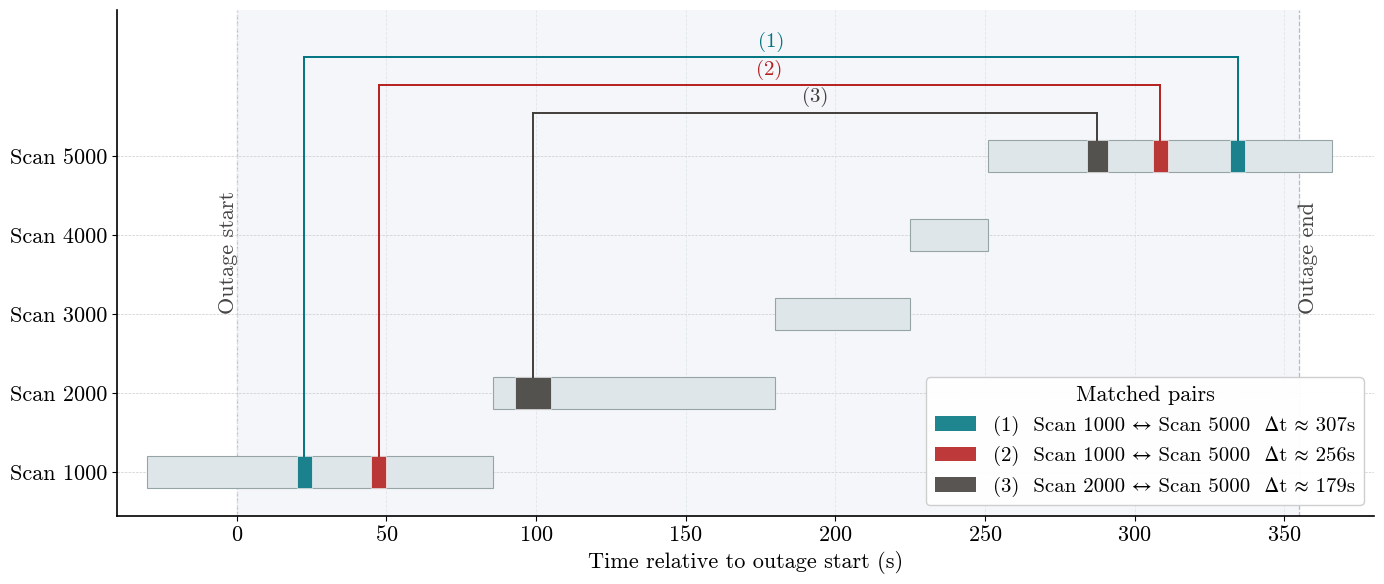

Done


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

FS = 16

fig, ax_cross = plt.subplots(figsize=(14, 6))

T_OUTAGE_START = 306290
T_OUTAGE_END   = 306645
T0 = T_OUTAGE_START
def tr(t): return t - T0

SCANLINES = {
    1000: (306260.0, 306375.6),
    2000: (306375.6, 306470.0),
    3000: (306470.0, 306514.9),
    4000: (306514.9, 306541.0),
    5000: (306541.0, 306655.8),
}

PAIRS_PLOT = [
    (1000, 306310, 306315, 5000, 306622, 306627),
    (1000, 306335, 306340, 5000, 306596, 306601),
    (2000, 306383, 306395, 5000, 306574, 306581),
]

COLORS_PLOT = [
    "#007480",
    "#B51F1F",
    "#413D3A",
]
BRIDGE_OFFSETS = [1.25, 0.90, 0.55]

SCAN_IDS = sorted(SCANLINES.keys())
y_map    = {sid: i for i, sid in enumerate(SCAN_IDS)}
N        = len(SCAN_IDS)

def intervals_overlap(a0, a1, b0, b1): return a0 < b1 and b0 < a1

scan_pair_windows = defaultdict(list)
for idx, pair in enumerate(PAIRS_PLOT):
    sA, tsA, teA, sB, tsB, teB = pair
    scan_pair_windows[sA].append((idx, tsA, teA, "A"))
    scan_pair_windows[sB].append((idx, tsB, teB, "B"))

segment_slot = {}
for sid, entries in scan_pair_windows.items():
    used = [False]*len(entries); groups = []
    for i in range(len(entries)):
        if used[i]: continue
        group = [i]; used[i] = True
        for j in range(i+1, len(entries)):
            if used[j]: continue
            for k in group:
                _, t0_, t1_, _ = entries[k]; _, t0j, t1j, _ = entries[j]
                if intervals_overlap(t0_, t1_, t0j, t1j):
                    group.append(j); used[j] = True; break
        groups.append(group)
    for group in groups:
        for slot, g_idx in enumerate(group):
            pidx, ts, te, role = entries[g_idx]
            segment_slot[(pidx, role)] = (slot, len(group))

def draw_segment(ax, y, ts, te, color, slot, n_slots):
    H_FULL = 0.4; h = H_FULL/n_slots
    y0 = y + H_FULL/2 - h/2 - slot*h
    ax.barh(y0, tr(te)-tr(ts), left=tr(ts), height=h,
            color=color, alpha=0.88, edgecolor="white", lw=0.5, zorder=3)

ax_cross.axvspan(tr(T_OUTAGE_START), tr(T_OUTAGE_END), color="#f5f6fa", zorder=0)
for xv in [tr(T_OUTAGE_START), tr(T_OUTAGE_END)]:
    ax_cross.axvline(xv, color="#b2bec3", lw=0.9, ls="--", zorder=1)

for sid, (ts, te) in SCANLINES.items():
    ax_cross.barh(y_map[sid], tr(te)-tr(ts), left=tr(ts), height=0.4,
                  color="#dfe6e9", edgecolor="#95a5a6", lw=0.8, zorder=2)

for idx, (pair, color) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT)):
    sA, tsA, teA, sB, tsB, teB = pair
    slot_A, n_A = segment_slot.get((idx,"A"),(0,1))
    slot_B, n_B = segment_slot.get((idx,"B"),(0,1))
    draw_segment(ax_cross, y_map[sA], tsA, teA, color, slot_A, n_A)
    draw_segment(ax_cross, y_map[sB], tsB, teB, color, slot_B, n_B)
    yA = y_map[sA]; yB = y_map[sB]
    xA = tr((tsA+teA)/2); xB = tr((tsB+teB)/2)
    y_bridge = max(yA,yB) + BRIDGE_OFFSETS[idx]
    ax_cross.plot([xA,xA],[yA+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xB,xB],[yB+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xA,xB],[y_bridge,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.text((xA+xB)/2, y_bridge+0.07, f"({idx+1})",
                  ha="center", va="bottom", fontsize=FS-1,
                  color=color, fontweight="bold")

ax_cross.set_yticks(list(y_map.values()))
ax_cross.set_yticklabels([f"Scan {sid}" for sid in SCAN_IDS], fontsize=FS)
ax_cross.set_xlabel("Time relative to outage start (s)", fontsize=FS)
ax_cross.tick_params(axis="both", labelsize=FS)
ax_cross.set_xlim(tr(306250), tr(306670))
ax_cross.set_ylim(-0.55, N + 0.85)
ax_cross.grid(axis="x", color="#dfe6e9", lw=0.6, zorder=0)
ax_cross.spines[["top","right"]].set_visible(False)

ax_cross.text(tr(T_OUTAGE_START)-3, N-3, "Outage start",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)
ax_cross.text(tr(T_OUTAGE_END)+3, N-3, "Outage end",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)

legend_handles = [
    mpatches.Patch(facecolor=c, alpha=0.88,
                   label=f"({i+1})  Scan {p[0]} ↔ Scan {p[3]}  "
                         f"Δt ≈ {p[4]-p[2]:.0f}s")
    for i, (p, c) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT))
]
ax_cross.legend(handles=legend_handles, fontsize=FS-1, ncol=1,
                loc="lower right", framealpha=0.95,
                title="Matched pairs", title_fontsize=FS)

plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/images/crossing_out3_relative_eval.png",
            bbox_inches="tight", dpi=400)
plt.show()
print("Done")